Accompanying Worksheets to Notes in [Introduction to Computational Physics](https://www.amazon.com/Introduction-Computational-Physics-Differential-Simulations/dp/B0GJD4DNNY).

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">

#  Worksheet 15: Radioactive Decay and Lotka-Volterra
- Implement radioactive decay analytically and numerically; compare;
- Lotka-Volterra: simulate and plot populations; interpret cycles;
- Use shooting method for boundary value problem.
</div>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp, quad

The general procedure to solve an ODE begins with defining the differential equation.  If it is a second-order equation, you will need to introduce additional variables and split it into multiple first-order differential equations.

## ODE method

1.  Reduce ODE to multiple first-order ODEs and define vector $\vec{y}$
2.  Write a function `def f(t,y):` returning $dy/dt$ as a vector
3.  Set initial conditions $\vec{y}_0$
4.  Define step size and time span with array $t$
5.  Call `sol = solve_ivp(f, (t0,tf), y0)`
6.  Graph solutions (`t`, `sol[:,j]`)  

## Radioactive Decay  

Isotopes on the periodic table can decay into stable materials following a specific chain sequence. We can model this radioactive decay chain with an ordinary differential equation, where the vector $\vec{x}$ contains all the materials and $\Lambda$ is a transition matrix:  

$$
\frac{d\vec{x}}{dt} = \Lambda \vec{x}
$$

The matrix $\Lambda$ can be constructed with the half-life times $T_j$ along the diagonal. The off-diagonal elements include the probability $b_{ij}$ for element $i$ to decay into $j$.

$$
  \Lambda_{ij} =
    \begin{cases}
      0 & \text{for $i<j$} \\
      -\frac{1}{T_j} & \text{for $i=j$}\\
      \frac{b_{ji}}{T_j} & \text{for $i>j$}
    \end{cases}       
$$

If, for example, radioactive isotope A has a decay time of 16 seconds into either B (5% chance) or C (95% chance) and element B decays with a half-life of 200 seconds into C. Element C is a stable element. We can calculate the amount of stable material C by solving the following matrix:

```{python}
l_A = [-1/16, 0, 0]
l_B = [0.05/16, -1/200, 0]
l_C = [0.95/16, 1/200, 0]
lambda_matrix = np.array([l_A, l_B, l_C])
```

The ODE function is simply the matrix $\Lambda$ multiplied with the vector $\vec{x}$. We will use the [numpy.matmul](https://numpy.org/doc/stable/reference/generated/numpy.tensordot.html) function that computes the tensor dot product.

```{python}
def radioactiveDecay(t, x):
    return np.matmul(lambda_matrix,x)
```

Imagine, we start with 5 kg starting material A and calculate the amount of material after 300 seconds. The initial condition is a vector with the amount of the three elements, i.e. `[5,0,0]`. This vector is propagated in time from 0s to 300s in time steps of 0.01s (small enough to capture the smallest decay time). Next, we invoke `solve_ivp` to solve the function with the starting condition `x0` over the time period `t`:

```{python}
x0 = np.array([5,0,0])
sol = solve_ivp(radioactiveDecay, (0,300),x0)
```

The result `sol` is a 2D matrix 30000 x 3 that includes time and elements. The last vector `sol[-1]` contains the amount of material after 300s, so `[0.036mg, 61g, 4.94kg]`, so almost all material decayed into the stable product C. 

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">


## Task 1: Radioactive Decay

Copy the code from above to calculate the decay and make a graph of the solution using the code below.
</div>

In [ ]:
# your code: copy from above
 

In [ ]:
 # Make the Graph
fig, ax = plt.subplots( )
t = sol['t']
A = sol['y'][0]
B = sol['y'][1]
C = sol['y'][2]
ax.plot(t,A, label="A")
ax.plot(t,B, label="B")
ax.plot(t,C, label = "C")
ax.set_xlabel("time t (s)")
ax.set_ylabel("mass m (kg)")
ax.legend()
plt.show()

## Lotka Volterra Model 

Fur trade has been important for centuries in much of the northern latitudes around the globe. Curiously, the Hudson's Bay Company (HBC) was given "sole trade and commerce" over Rupert's Land in the 1670 charter. Rupert was the cousin of the English king. This privately owned land comprised of about 3.9 million square kilometers territory in what is now Canada. This lasted for about 200 years until HBC surrendered its charter to the British Crown. In 1868, Rupert's Land was sold to Canada. Due to HBC's monopoly status, excellent records of hare and lynx populations can be reconstructed based on the annual sales of furs, which were all channeled through HBC. The lynx pelts fluctuated from about 5000 to 50000 pelts per year, while the hares' pelts fluctuated between 10000 and 80000 pelts per year. The oscillation peaks were about 2 years apart and had a periodicity of about 10 years. After hares became abundant, the lynx population quickly grew, but then the hare population collapsed, which meant that the lynx population soon after decreased as well. The population stability can be studied with differential equations.

In the Lotka-Volterra [predator-prey model](https://en.wikipedia.org/wiki/Lotka%E2%80%93Volterra_equations) the populations of two dependent species $[y_1, y_2]$ vary as follows:

$$
\frac{dy_1}{dt} = \alpha y_1 - \beta y_1 y_2, \quad
\frac{dy_2}{dt} = -\gamma y_2 + \delta y_1 y_2
$$

Here $y_1$ could be the population of the prey and $y_2$ could be the population of the predator.

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">


## Task 2: Lotka-Volterra Equation

Implement the Lotka-Volterra equation. Use $\alpha = 2/3$ and $\beta=4/3$ and $\gamma=1$ and $\delta=1$.

As a initial value use $y_1(0)=1$ and $y_2(0)=1$.

Then graph the resuls from solving the coupled ODEs using the code below.
</div>

In [ ]:
# Your code to solve the Lotka-Volterra equations
 
# sol = solve_ivp(LotkaVolterra, (0,40), y0, args=(a,b,c,d), t_eval=t)

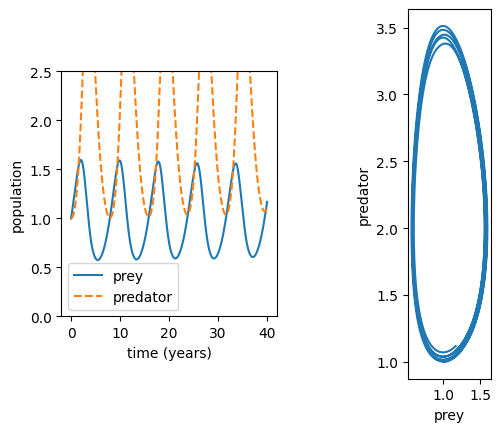

In [24]:
#  Redo `solve_ivp` and then graph solutions y(t): using `t_span` parameter to smoothen out.
fig, ax = plt.subplots(1,2)
fig.subplots_adjust(wspace=0.3)
ax[1].plot(sol['y'][0],sol['y'][1])
ax[1].set_aspect(aspect=1.8)
ax[1].set_xlabel("prey")
ax[1].set_ylabel("predator")

t = sol['t']
ax[0].plot(t, sol['y'][0], label='prey')
ax[0].plot(t, sol['y'][1], label='predator',ls='--')
ax[0].set_aspect(aspect=20)
ax[0].set_xlabel("time (years)")
ax[0].set_ylabel("population")
ax[0].set_ylim(0,2.5)
ax[0].legend()

plt.show()

## Shooting Method  

Many physics problems cannot be solved as an initial value problem (IVP), but rather as a *boundary value* problem (BVP). These problems are a bit more complex to solve, but one intuitive method is called the *shooting method*. Recall that the IVP for a second-order differential equation requires you to provide two initial parameters; for example the position and speed. In the shooting method, you provide the initial and final positions instead; the result is a trajectory that complies with the boundary conditions. 

It is possible to convert the BVP into an initial value problem, by tuning a value $\alpha$; then solving the ODE for a fixed value of $\alpha$ to find the end position.   It would be sheer luck, if the end position would fit the boundary value. However, by adjusting $\alpha$, we should be able to tune the system to eventually meet the desired value. Usually this involves some kind of root finding method.

Common situations for BVP include flows in a tube, heat distribution over a region, electric fields from a charge distribution, or waves with restricted ends. The latter is also related to quantum mechanics, especially the time-independent Schr&ouml;dinger equation.

An illustration of applying the shooting method could be finding $x(t)$ for the following differential equation:  

$$
\frac{dx^2}{dt^2} = -8x
$$

Given that $x(0)=0$ and $x(1)=0.8$. You can find the solution analytically, but our method involves a general, numerical solution. In the first step, we convert this equation into two first-order differential equations. 

```{python}
def fun_osc(t, y):
  x,v = y
  return [v, -8*x]
```

Previously, we could solve this equation, if we are given the initial conditions $x_0$ and $v_0$. Instead of $v_0$, we are provided with $x_f$. Therefore, we pick a non-zero $v_0=\alpha$ value arbitrarily and check whether we meet the goal. If it does not fit the boundary condition, then we repeat for a different value of $\alpha$. 

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">


## Task 3: Shooting Method

Solve the previous differential equation for $x(0)=0$ and $x(1)=0.8$. Write a function that solves this differential equation and returns the last value of the calculation; i.e. $x(1)$. The function uses $x(0)=0$ and $v(0)=\alpha$, where $\alpha$ is a variable that you can define. Then run the function with a random value of $\alpha$ and try to guess the right value, so that we have $x(1)=0.8$.

$$
\frac{dx^2}{dt^2} = -8x
$$

</div>

In [9]:
# your code: #


## Discussion

Add any additional questions or comments.

The End.